# Checking the optimal amount of training steps

In [13]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# Load and parse data once
df = pd.read_csv("validate_steps.csv")

def parse_model_metadata(model_name: str):
    name = str(model_name).replace(".zip", "")
    traffic_type = "fixed" if "fixed" in name else "random" if "random" in name else "unknown"
    match = re.search(r"_(\d+)([kKmM]?)_steps$", name) or re.search(r"_(\d+)([kKmM]?)$", name)
    if not match:
        return traffic_type, None
    steps = int(match.group(1))
    suffix = match.group(2).lower()
    if suffix == "k":
        steps *= 1_000
    elif suffix == "m":
        steps *= 1_000_000
    return traffic_type, steps

meta = df["model_name"].apply(parse_model_metadata)
df[["traffic_type", "steps"]] = pd.DataFrame(meta.tolist(), index=df.index)
df = df[df["traffic_type"].isin(["fixed", "random"]) & df["steps"].notna()].copy()
df["steps"] = df["steps"].astype(int)
df["route_label"] = df["route_file"].str.replace("routes_valid_", "", regex=False).str.replace(".rou", "", regex=False)


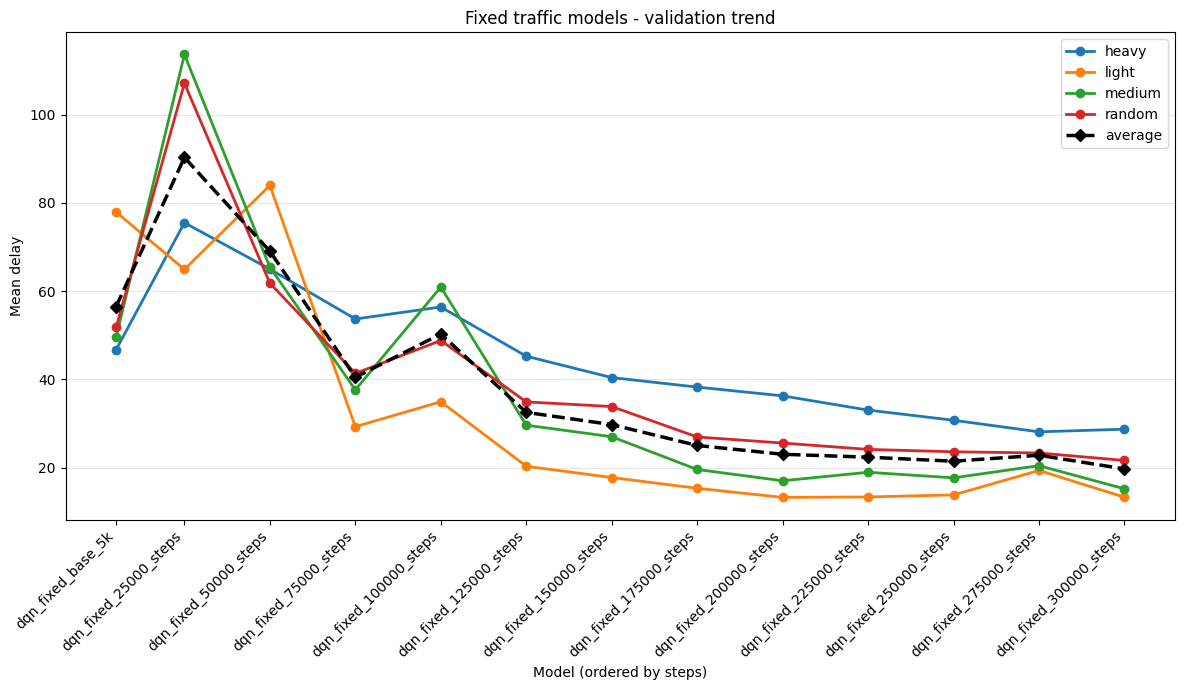

Fixed models:
            model_name  steps  mean_delay  improvement_vs_prev
     dqn_fixed_base_5k   5000   56.481554                  NaN
 dqn_fixed_25000_steps  25000   90.319823           -33.838269
 dqn_fixed_50000_steps  50000   69.047283            21.272540
 dqn_fixed_75000_steps  75000   40.474534            28.572749
dqn_fixed_100000_steps 100000   50.261175            -9.786641
dqn_fixed_125000_steps 125000   32.501740            17.759436
dqn_fixed_150000_steps 150000   29.732615             2.769125
dqn_fixed_175000_steps 175000   24.999814             4.732801
dqn_fixed_200000_steps 200000   23.002659             1.997155
dqn_fixed_225000_steps 225000   22.342501             0.660158
dqn_fixed_250000_steps 250000   21.430627             0.911874
dqn_fixed_275000_steps 275000   22.780759            -1.350132
dqn_fixed_300000_steps 300000   19.678708             3.102050


In [14]:
# Fixed traffic models
fixed = df[df["traffic_type"] == "fixed"].copy()
if not fixed.empty:
    model_order_df = fixed[["model_name", "steps"]].drop_duplicates().sort_values("steps")
    step_to_model = dict(zip(model_order_df["steps"], model_order_df["model_name"]))

    plt.figure(figsize=(12, 7))
    for route_label, group in fixed.groupby("route_label", sort=False):
        g = group.groupby("steps", as_index=False)["mean_delay"].mean().sort_values("steps")
        plt.plot(g["steps"], g["mean_delay"], marker="o", linewidth=2, label=route_label)

    avg = fixed.groupby("steps", as_index=False)["mean_delay"].mean().sort_values("steps")
    plt.plot(avg["steps"], avg["mean_delay"], marker="D", linestyle="--", linewidth=2.5, color="black", label="average")

    ticks = sorted(step_to_model.keys())
    plt.xticks(ticks, [step_to_model[s] for s in ticks], rotation=45, ha="right")
    plt.xlabel("Model (ordered by steps)")
    plt.ylabel("Mean delay")
    plt.title("Fixed traffic models - validation trend")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    avg["improvement_vs_prev"] = avg["mean_delay"].shift(1) - avg["mean_delay"]
    avg["model_name"] = avg["steps"].map(step_to_model)
    print("Fixed models:")
    print(avg[["model_name", "steps", "mean_delay", "improvement_vs_prev"]].to_string(index=False))


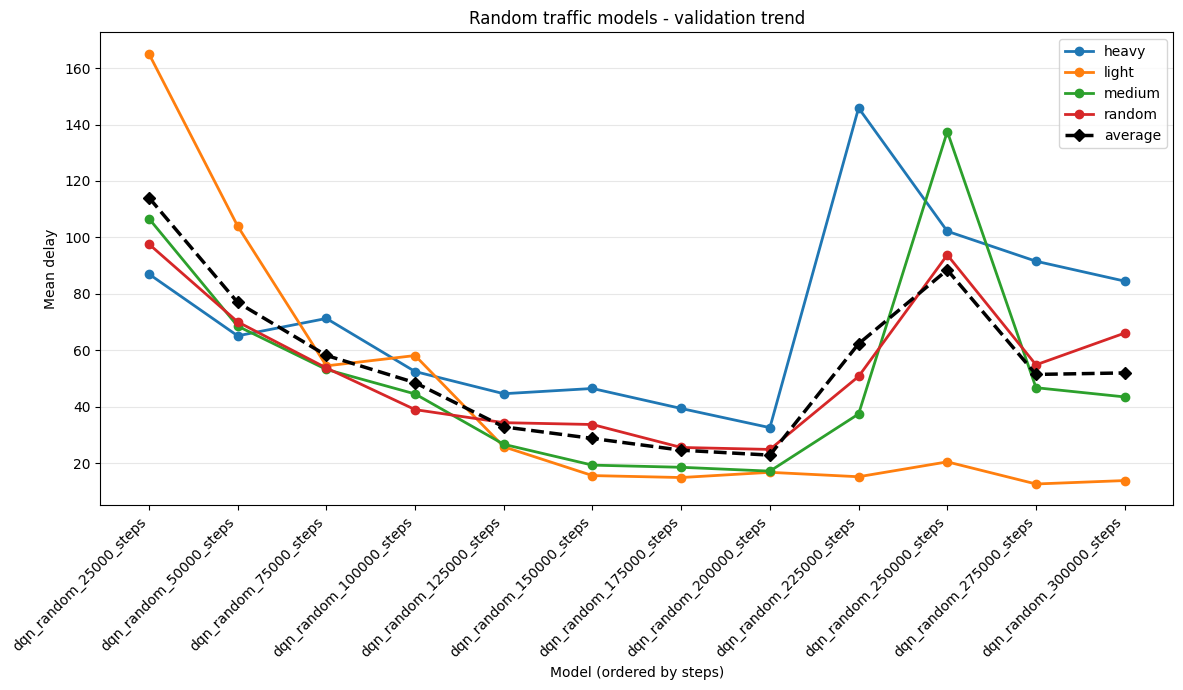

Random models:
             model_name  steps  mean_delay  improvement_vs_prev
 dqn_random_25000_steps  25000  114.080100                  NaN
 dqn_random_50000_steps  50000   76.924350            37.155750
 dqn_random_75000_steps  75000   58.158161            18.766188
dqn_random_100000_steps 100000   48.508601             9.649561
dqn_random_125000_steps 125000   32.839157            15.669444
dqn_random_150000_steps 150000   28.742079             4.097078
dqn_random_175000_steps 175000   24.574591             4.167488
dqn_random_200000_steps 200000   22.821418             1.753174
dqn_random_225000_steps 225000   62.284808           -39.463390
dqn_random_250000_steps 250000   88.471759           -26.186952
dqn_random_275000_steps 275000   51.425842            37.045917
dqn_random_300000_steps 300000   51.959899            -0.534056


In [15]:
# Random traffic models
random = df[df["traffic_type"] == "random"].copy()
if not random.empty:
    model_order_df = random[["model_name", "steps"]].drop_duplicates().sort_values("steps")
    step_to_model = dict(zip(model_order_df["steps"], model_order_df["model_name"]))

    plt.figure(figsize=(12, 7))
    for route_label, group in random.groupby("route_label", sort=False):
        g = group.groupby("steps", as_index=False)["mean_delay"].mean().sort_values("steps")
        plt.plot(g["steps"], g["mean_delay"], marker="o", linewidth=2, label=route_label)

    avg = random.groupby("steps", as_index=False)["mean_delay"].mean().sort_values("steps")
    plt.plot(avg["steps"], avg["mean_delay"], marker="D", linestyle="--", linewidth=2.5, color="black", label="average")

    ticks = sorted(step_to_model.keys())
    plt.xticks(ticks, [step_to_model[s] for s in ticks], rotation=45, ha="right")
    plt.xlabel("Model (ordered by steps)")
    plt.ylabel("Mean delay")
    plt.title("Random traffic models - validation trend")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    avg["improvement_vs_prev"] = avg["mean_delay"].shift(1) - avg["mean_delay"]
    avg["model_name"] = avg["steps"].map(step_to_model)
    print("Random models:")
    print(avg[["model_name", "steps", "mean_delay", "improvement_vs_prev"]].to_string(index=False))
else:
    print("No random traffic data found.")


# Hyperparameter tuning of a fixed model

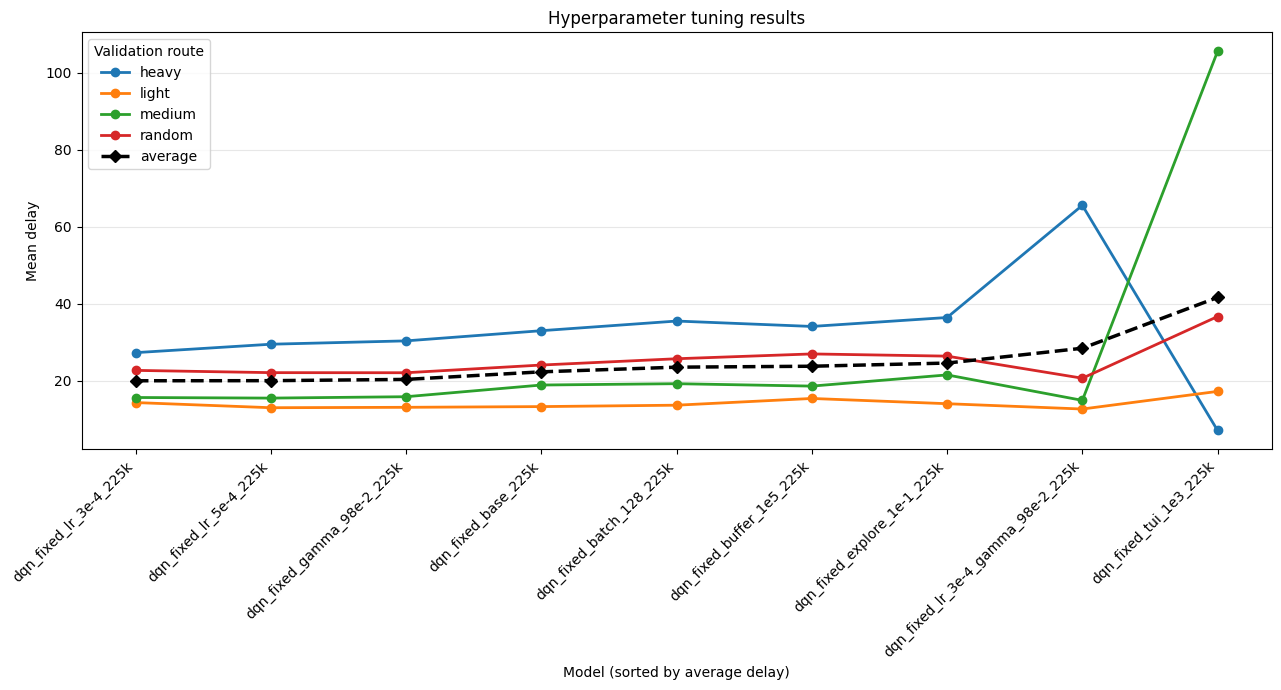

Model ranking by average mean_delay (lower is better):
model_name
dqn_fixed_lr_3e-4_225k                20.024190
dqn_fixed_lr_5e-4_225k                20.050231
dqn_fixed_gamma_98e-2_225k            20.377475
dqn_fixed_base_225k                   22.342501
dqn_fixed_batch_128_225k              23.554451
dqn_fixed_buffer_1e5_225k             23.797109
dqn_fixed_explore_1e-1_225k           24.619719
dqn_fixed_lr_3e-4_gamma_98e-2_225k    28.468287
dqn_fixed_tui_1e3_225k                41.657137


In [16]:
# Independent hyperparameter comparison (no model-name parsing needed)
hp = pd.read_csv("validation_results.csv")
hp["route_label"] = hp["route_file"].str.replace("routes_valid_", "", regex=False).str.replace(".rou", "", regex=False)

# Rows: model_name, columns: route, values: mean_delay
pivot = hp.pivot_table(index="model_name", columns="route_label", values="mean_delay", aggfunc="mean")
pivot["avg_delay"] = pivot.mean(axis=1)
pivot = pivot.sort_values("avg_delay")

plt.figure(figsize=(13, 7))
for route in [c for c in pivot.columns if c != "avg_delay"]:
    plt.plot(pivot.index, pivot[route], marker="o", linewidth=2, label=route)

plt.plot(
    pivot.index,
    pivot["avg_delay"],
    marker="D",
    linestyle="--",
    linewidth=2.5,
    color="black",
    label="average",
)

plt.xlabel("Model (sorted by average delay)")
plt.ylabel("Mean delay")
plt.title("Hyperparameter tuning results")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Validation route")
plt.tight_layout()
plt.show()

print("Model ranking by average mean_delay (lower is better):")
print(pivot["avg_delay"].to_string())


# Visualising final results

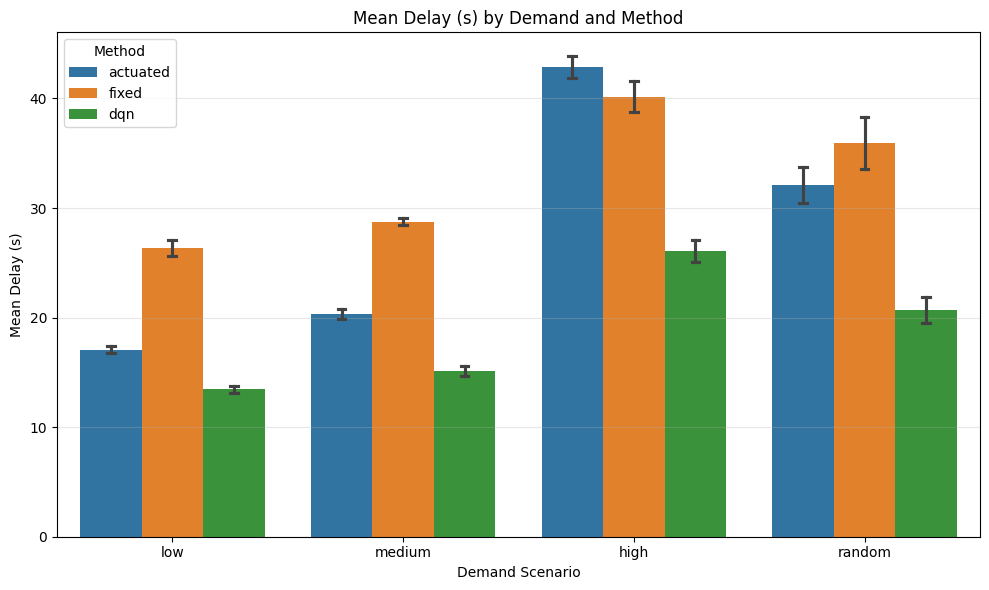

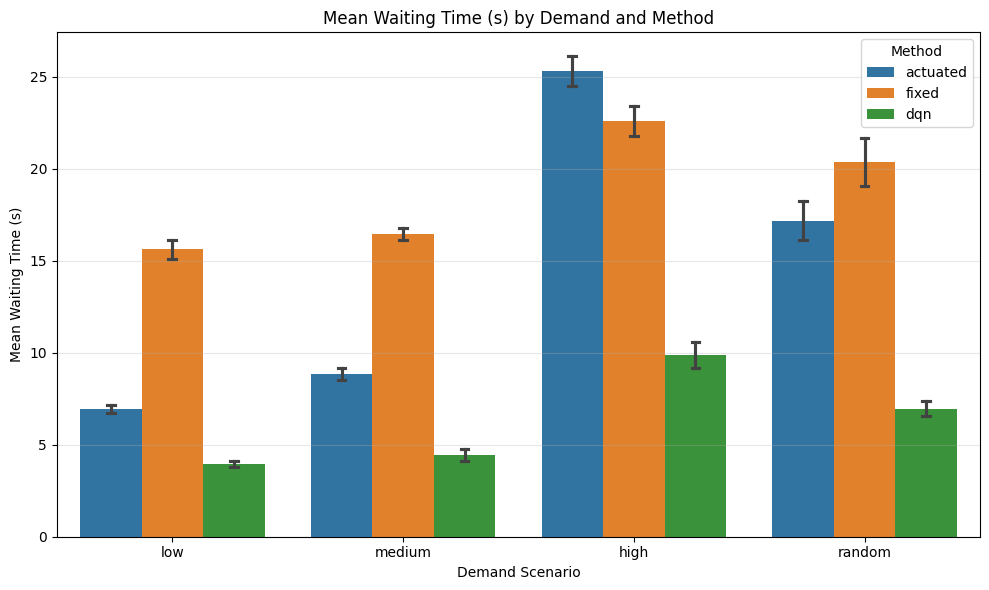

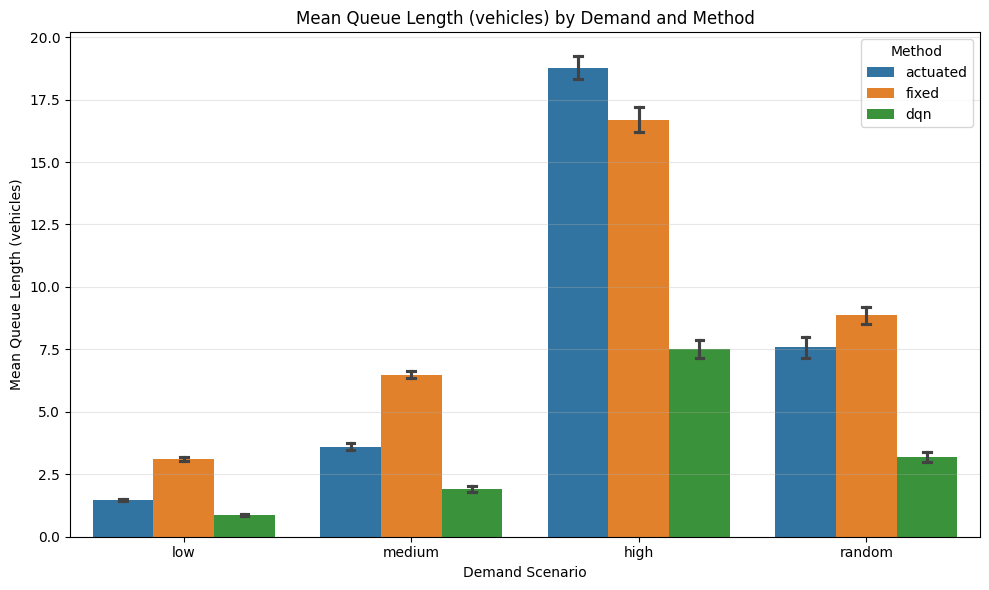

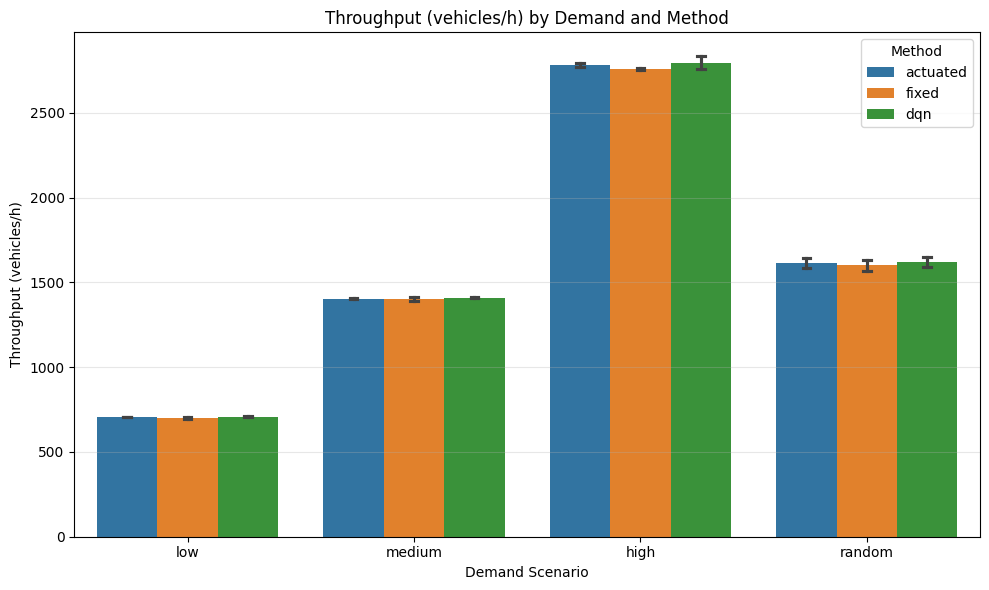

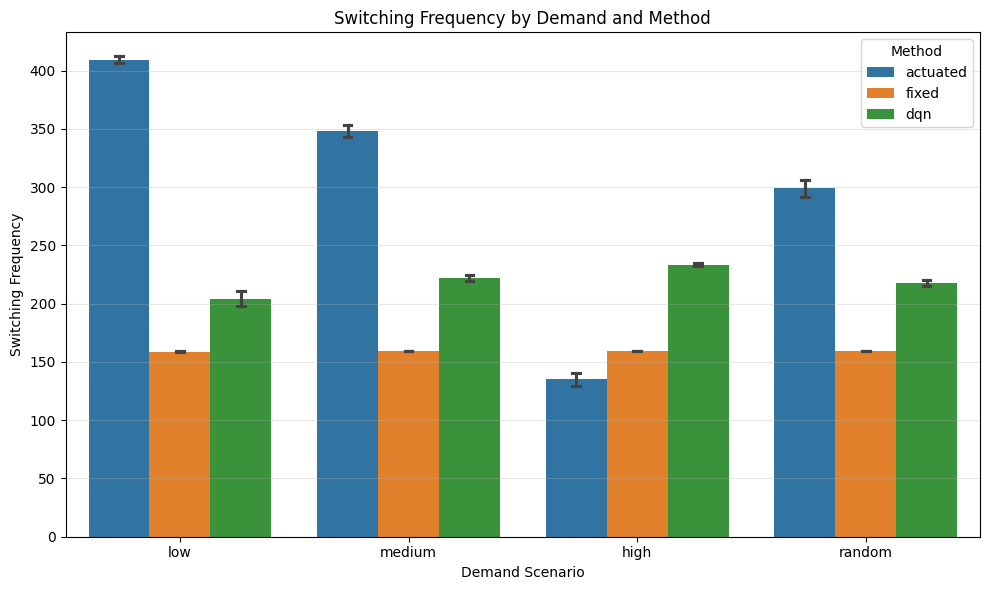

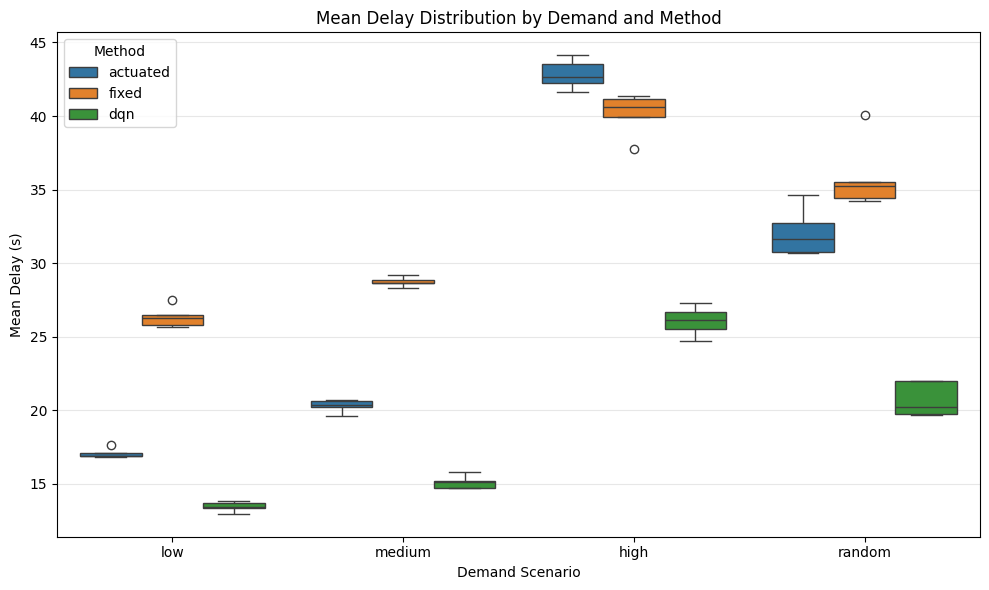

In [17]:
import seaborn as sns

res = pd.read_csv("results.csv")
demand_order = ["low", "medium", "high", "random"]

metrics = [
    ("mean_delay", "Mean Delay (s)"),
    ("mean_waiting", "Mean Waiting Time (s)"),
    ("mean_queue", "Mean Queue Length (vehicles)"),
    ("throughput", "Throughput (vehicles/h)"),
    ("switching_freq", "Switching Frequency")
]

for col, ylabel in metrics:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=res, x="demand", y=col, hue="method", order=demand_order, errorbar="sd", capsize=0.1)
    plt.title(f"{ylabel} by Demand and Method")
    plt.ylabel(ylabel)
    plt.xlabel("Demand Scenario")
    plt.legend(title="Method")
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=res, x="demand", y="mean_delay", hue="method", order=demand_order)
plt.title("Mean Delay Distribution by Demand and Method")
plt.ylabel("Mean Delay (s)")
plt.xlabel("Demand Scenario")
plt.legend(title="Method")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
